# Character distance and SoulX FlashHead lip-sync output

## tl;dr

In this controlled one-avatar, one-utterance test, apparent face scale changed the generated mouth trajectory. Relative to the close framing, medium framing preserved timing reasonably well (mean same-seed zero-lag correlation **0.809**, no best-fit shift) but produced **26.7% higher mean normalized mouth opening**. Far framing had weaker trajectory agreement (**0.602**) and matched best after a **one-frame / 40 ms phase adjustment** in both seeds. This is evidence that framing affects the output, but it is not a phoneme-level or human-rated lip-sync score.


## Context & Methods

The experiment operationalizes character distance as apparent subject scale within a fixed 320×576 reference frame: close 1.00, medium 0.72, and far 0.50. Identity, source portrait, 10-second audio, model/profile, and seeds (50 and 51) are held fixed.

**GPU provenance:** NVIDIA GeForce RTX 4070 SUPER, 12,282 MiB visible VRAM; driver 595.84; measured 2026-09-16. Evidence is the `nvidia-smi` query saved in `evidence-20260916/results.json`. GPU generation used SoulX FlashHead Lite; MediaPipe landmark analysis was CPU-side (its renderer reported the same GPU/OpenGL device but that is not generation provenance).

### Key Assumptions

- Image-space scale is a practical proxy for screen/camera distance.
- Normalized inner-lip opening is a motion-output diagnostic, not a perceptual or phoneme-accuracy metric.
- The blurred-background compositing used to create smaller subjects is a remaining visual confound, so the result applies to these framing variants rather than physical distance alone.


## Data

Inputs: `evidence-20260916/results.json` and `evidence-20260916/mouth-motion.json`. Each of the six clips contains 250 frames at 25 FPS.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

evidence = Path('evidence-20260916')
run = json.loads((evidence / 'results.json').read_text())
motion = json.loads((evidence / 'mouth-motion.json').read_text())
rows = pd.DataFrame([{k: v for k, v in row.items() if k != 'opening_series'} for row in motion['rows']])
comparisons = pd.DataFrame([{k: v for k, v in row.items() if k != 'lag_scan_frames'} for row in motion['comparisons']])
assert run['status'] == 'complete' and len(rows) == 6 and (rows['frames'] == 250).all()
assert (rows['detection_rate'] == 1).all()
rows.sort_values(['distance', 'seed'])

,distance,seed,frames,detected,detection_rate,mean_face_width_px,mean_eye_span_px,mean_opening,p95_opening,opening_sd,mean_abs_frame_change
0,close,50,250,250,1.0,233.423425,155.150983,0.056529,0.133051,0.043048,0.016044
1,close,51,250,250,1.0,233.609847,155.954229,0.055582,0.123334,0.038382,0.013500
2,far,50,250,250,1.0,118.805007,79.224364,0.058771,0.127068,0.043492,0.014139
3,far,51,250,250,1.0,118.290434,78.912294,0.064576,0.176889,0.052109,0.016814
4,medium,50,250,250,1.0,168.841731,112.448829,0.069326,0.173339,0.050341,0.017007
5,medium,51,250,250,1.0,169.535778,112.868001,0.072703,0.170060,0.052295,0.015688


## Results

In [2]:
order = ['close', 'medium', 'far']
summary = rows.groupby('distance').agg(
    face_width_px=('mean_face_width_px', 'mean'),
    eye_span_px=('mean_eye_span_px', 'mean'),
    mean_opening=('mean_opening', 'mean'),
    p95_opening=('p95_opening', 'mean'),
    opening_sd=('opening_sd', 'mean'),
    detection_rate=('detection_rate', 'mean'),
).reindex(order)
summary['mean_opening_change_vs_close_pct'] = (summary['mean_opening'] / summary.loc['close', 'mean_opening'] - 1) * 100
summary['p95_opening_change_vs_close_pct'] = (summary['p95_opening'] / summary.loc['close', 'p95_opening'] - 1) * 100
summary.round(4)

,face_width_px,eye_span_px,mean_opening,p95_opening,opening_sd,detection_rate,mean_opening_change_vs_close_pct,p95_opening_change_vs_close_pct
distance,,,,,,,,
close,233.5166,155.5526,0.0561,0.1282,0.0407,1.0,0.0000,0.0000
medium,169.1888,112.6584,0.0710,0.1717,0.0513,1.0,26.6853,33.9389
far,118.5477,79.0683,0.0617,0.1520,0.0478,1.0,10.0218,18.5550


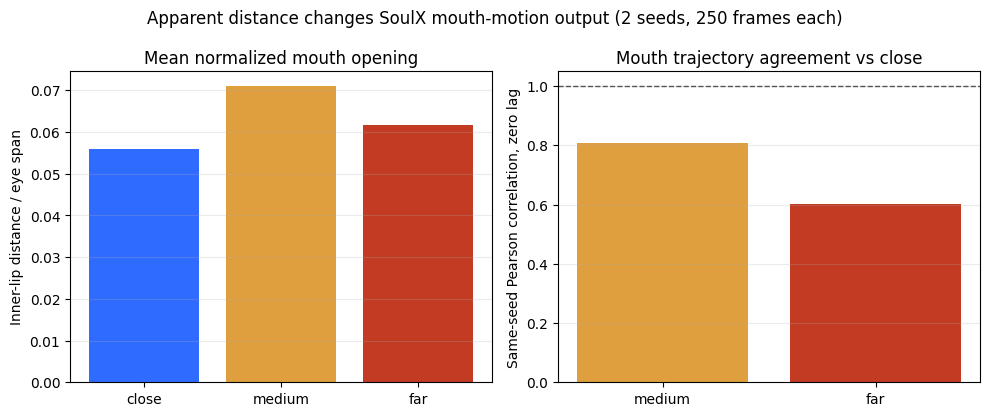

In [3]:
close_color, medium_color, far_color = '#2F6BFF', '#E09F3E', '#C23B22'
colors = [close_color, medium_color, far_color]
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
axes[0].bar(order, summary.loc[order, 'mean_opening'], color=colors)
axes[0].set_title('Mean normalized mouth opening')
axes[0].set_ylabel('Inner-lip distance / eye span')
axes[0].grid(axis='y', alpha=.25)

corr = comparisons.groupby('distance')['zero_lag_correlation_vs_close'].mean().reindex(['medium', 'far'])
axes[1].bar(corr.index, corr.values, color=[medium_color, far_color])
axes[1].axhline(1, color='#555', lw=1, ls='--')
axes[1].set_ylim(0, 1.05)
axes[1].set_title('Mouth trajectory agreement vs close')
axes[1].set_ylabel('Same-seed Pearson correlation, zero lag')
axes[1].grid(axis='y', alpha=.25)
fig.suptitle('Apparent distance changes SoulX mouth-motion output (2 seeds, 250 frames each)')
fig.tight_layout()
fig.savefig(evidence / 'distance-effect.png', dpi=160, bbox_inches='tight')
plt.show()

Medium framing keeps the broad timing pattern but increases mouth-opening magnitude. Far framing is less consistent with the close trajectory and also less repeatable across the two seeds. All faces remained detectable, so the drop is not caused by missing landmark tracks.

In [4]:
series = {(row['distance'], row['seed']): row['opening_series'] for row in motion['rows']}
def paired_corr(a, b):
    pairs = [(x, y) for x, y in zip(a, b) if x is not None and y is not None]
    return float(np.corrcoef(np.array(pairs).T)[0, 1])

cross_seed = pd.Series({distance: paired_corr(series[(distance, 50)], series[(distance, 51)]) for distance in order}, name='seed50_vs_seed51_zero_lag_correlation')
cross_seed.to_frame().round(3)

,seed50_vs_seed51_zero_lag_correlation
close,0.848
medium,0.852
far,0.546


## Takeaways

1. **Yes—apparent distance/framing affects the generated lip motion in this test.** The effect is already visible at medium scale in opening magnitude and becomes stronger at far scale in trajectory shape.
2. **Medium is the safer tested range.** It retained a mean zero-lag correlation of 0.809 with the close baseline, versus 0.602 for far.
3. **Far framing is less stable.** Its two seeds correlated only 0.546 with each other, compared with 0.848 close and 0.852 medium.
4. **Do not interpret the 40 ms phase adjustment as a certified audiovisual offset.** It is a one-frame alignment difference between generated mouth-opening trajectories, not a SyncNet, phoneme, or human-perception measurement.
5. A production decision needs more identities, natural far-shot references (without synthetic compositing), multiple utterances/languages, and a proper audiovisual metric or blinded human review.
